In [9]:
import pandas as pd
from sqlalchemy import create_engine

import sys
sys.path.append('../..')
from final_project.scripts.data_analysis_utils import setup_categorical_type

import matplotlib.pyplot as plt


In [3]:
engine = create_engine('sqlite:///../data/database.db')

In [7]:
query = """
SELECT time_period, region, AVG(perc_retained) AS avg_perc_retained
FROM retention
GROUP BY region, time_period
ORDER BY time_period, region
"""
pd.read_sql(query, engine)

,time_period,region,avg_perc_retained
0,2019 to 20,East Midlands,90.3332
1,2019 to 20,East of England,90.5544
2,2019 to 20,London,90.5096
3,2019 to 20,North East,89.0708
4,2019 to 20,North West,87.8370
5,2019 to 20,South East,89.0352
6,2019 to 20,South West,88.9110
7,2019 to 20,West Midlands,89.1774
8,2019 to 20,Yorkshire and The Humber,89.0922
9,2020 to 21,East Midlands,89.9976


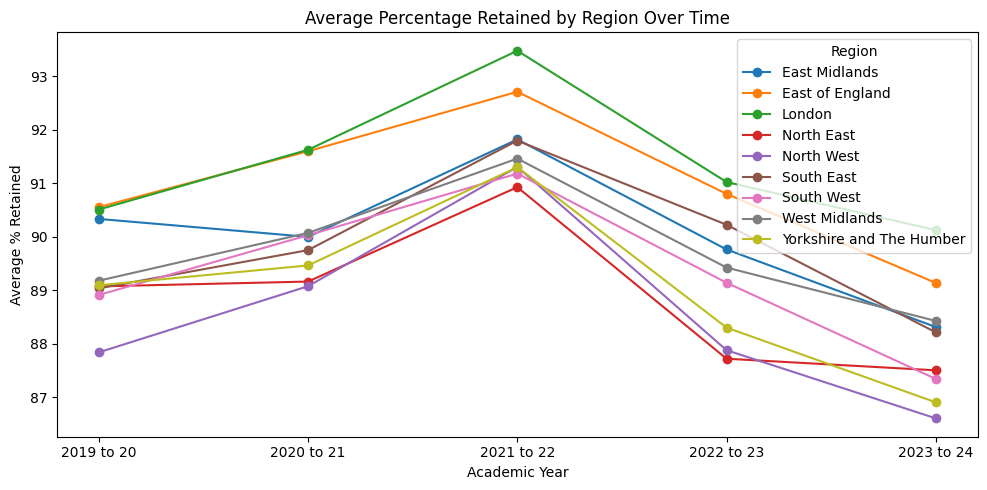

In [ ]:
perc_retained_df = pd.read_sql(query, engine)
pivot_df = perc_retained_df.pivot(index="time_period", columns="region", values="avg_perc_retained")


plt.figure(figsize=(10, 5))
plt.plot(pivot_df, marker="o", label=pivot_df.columns)

plt.xlabel("Academic Year")
plt.ylabel("Average % Retained")
plt.title("Average Percentage Retained by Region Over Time")
plt.legend(title="Region", loc="upper right")

plt.tight_layout()
plt.show()

In [28]:
query = """
SELECT
    region,
    characteristic_value AS sex,
    SUM(number_of_a_level_students) AS num_entering_a_levels,
    SUM(number_of_students_entered) AS total_students
FROM characteristics
WHERE characteristic_type = 'Sex'
  AND characteristic_value IN ('Male', 'Female')
GROUP BY region, characteristic_value
"""

heatmap_df = pd.read_sql(query, engine)
heatmap_df["perc_entering_a_levels"] = (heatmap_df["num_entering_a_levels"] / heatmap_df["total_students"]) * 100
heatmap_df
# pivot_heatmap = heatmap_df.pivot(index="region_name", columns="sex", values="perc_entering_alevels")

# plt.figure(figsize=(8, 6))
# import seaborn as sns
# sns.heatmap(pivot_heatmap, annot=True, fmt=".1f", cmap="YlGnBu")
# plt.title("Percentage Entering A-levels by Region and Sex")
# plt.xlabel("Sex")

,region,sex,num_entering_a_levels,total_students,perc_entering_a_levels
0,East Midlands,Female,53228,206574,25.767037
1,East Midlands,Male,41938,169053,24.807605
2,East of England,Female,79497,315098,25.229294
3,East of England,Male,66018,273119,24.171881
4,London,Female,122620,453558,27.035131
5,London,Male,99263,399603,24.840404
6,North East,Female,27156,116084,23.393405
7,North East,Male,20470,92599,22.106070
8,North West,Female,88037,351651,25.035333
9,North West,Male,67975,287159,23.671555


In [ ]:
# Pivot chars_df to get percentage entering A-levels by region and sex
heatmap_df = chars_df[
    (chars_df["characteristic_type"] == "Sex") &
    (chars_df["characteristic_value"].isin(["Male", "Female"]))
].groupby(["region_name", "characteristic"]).agg(
    num_entering_alevels=("number_of_a_level_students", "sum"),
    total_students=("number_of_students_entered", "sum")
).reset_index()

heatmap_df["perc_entering_alevels"] = (
    heatmap_df["perc_entering_alevels"] / heatmap_df["total_students"] * 100
)

pivot_heatmap = heatmap_df.pivot(index="region_name", columns="characteristic", values="perc_entering_alevels")

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_heatmap, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Percentage Entering A-levels by Region and Sex")
plt.xlabel("Sex")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

NameError: name 'chars_df' is not defined

In [ ]:
rurality_df["dropout_rate"] = (rurality_df["number_of_students_entered"] - 
                               rurality_df["number_of_students_potential"])/ rurality_df["number_of_students_entered"]

rurality_df["pc_of_students_doing_alev"] = (rurality_df["number_of_students_alev"] / rurality_df["number_of_students_entered"]) * 100

In [ ]:
chars_df.groupby("region_name").apply(lambda x: x.isnull().sum(), include_groups=False)

In [ ]:
chars_df[chars_df["number_of_students_potential"].isnull()]

In [ ]:
chars_df["characteristic_type"].unique()

In [ ]:
grouped = chars_df[(chars_df["characteristic_type"]=="All Students")].groupby(
    ["region_name"]).agg({
    "number_of_students_acad":"sum",
    "number_of_students_alev": "sum",
    "number_of_students_potential": "sum",
    "aps_per_entry_grade_acad": lambda x: x.mode()[0],
    "aps_per_entry_grade_alev": lambda x: x.mode()[0]
    })

total_row = grouped.sum(numeric_only=True)
total_row.name = 'Total'
grouped_with_total = pd.concat([grouped, total_row.to_frame().T])

grouped_with_total

In [ ]:
rurality_df["number_of_students_entered"] = rurality_df[["number_of_students_level3", "number_of_students_alev",
                                                            "number_of_students_acad", "number_of_students_agen",
                                                            "number_of_students_tlev", "number_of_students_technicalcertificate"]].sum(axis=1)

rurality_df["dropout_rate"] = (rurality_df["number_of_students_entered"] - 
                               rurality_df["number_of_students_potential"])/ rurality_df["number_of_students_entered"]

rurality_df["pc_of_students_doing_alev"] = (rurality_df["number_of_students_alev"] / rurality_df["number_of_students_entered"]) * 100


# rurality_df.drop(columns=["number_of_students_level3", "number_of_students_alev",
#                        "number_of_students_acad", "number_of_students_agen",
#                           "number_of_students_tlev", "number_of_students_technicalcertificate"], inplace=True)
